# Exploratory Data Analysis!
In this notebook, I will load a few audio files from my dataset with librosa, just to see what we're working with.

In [1]:
# data anlysis libraries
import pandas as pd
import numpy as np

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# glob
from glob import glob

# audio processing libraries
import librosa
import librosa.display
import os

In [16]:
# save all audio files in the raw data directory
audio_files = glob("../data/raw/*.wav")
print(f'Top 5 files: {audio_files[:5]}')

Top 5 files: ['../data/raw\\B_ANI01_MC_FN_SIM01_101.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_102.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_103.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_301.wav', '../data/raw\\B_ANI01_MC_FN_SIM01_302.wav']


In [ ]:
# save numpy array for audio file (y) and sample rate (sr)
y, sr = librosa.load(audio_files[0])
print(f'y: {y[:10]}')
print(f"Shape y: {y.shape}, Sample Rate: {sr}")

y: [-9.1832391e-08 -2.5374214e-07 -1.8483684e-07  1.2441542e-07
  3.0783772e-07  1.5577265e-07 -1.7498628e-07 -3.3151454e-07
 -1.2974749e-07  2.2750578e-07]
Shape y: (50308,), Sample Rate: 22050


Text(0.5, 1.0, 'Raw Audio Signal')

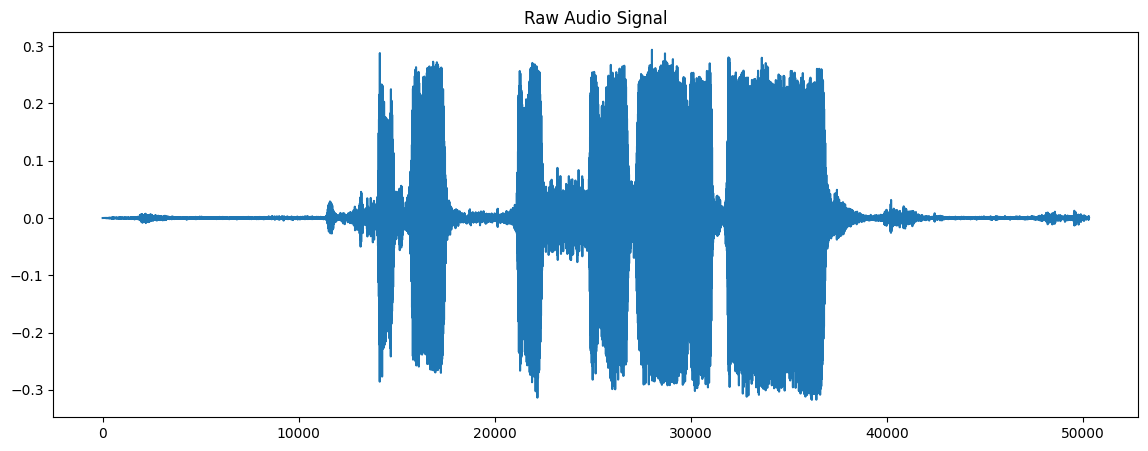

In [ ]:
# plot the raw audio signal using pandas and matplotlib
pd.Series(y).plot(figsize=(14, 5))
plt.title("Raw Audio Signal")

y_trimmed: [ 0.00150274 -0.0031554  -0.00524788 -0.00509775 -0.00440349 -0.00420725
 -0.00379539 -0.00162763  0.00260786  0.00689141]


Text(0.5, 1.0, 'Trimmed Audio Signal')

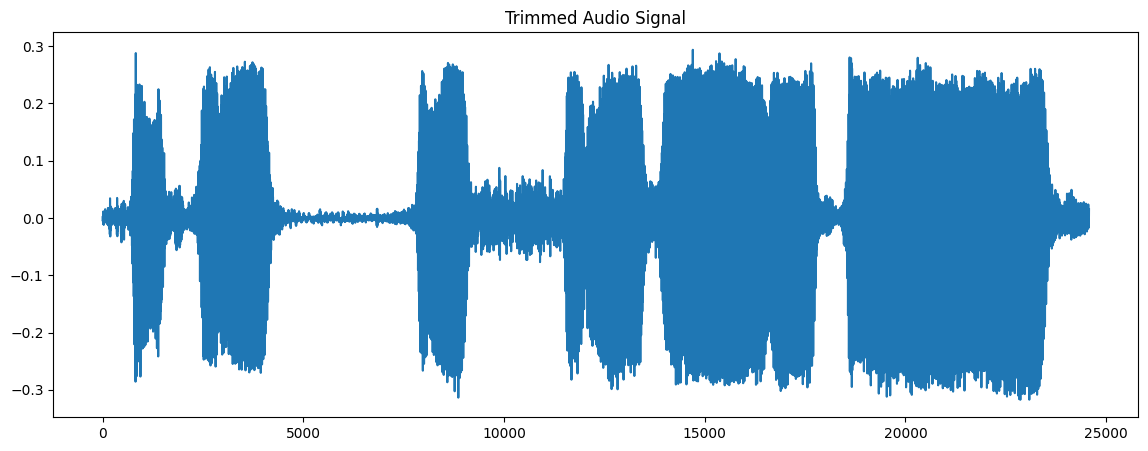

In [17]:
# trim out silence from the beginning and end of the audio signal
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
print(f'y_trimmed: {y_trimmed[:10]}')
pd.Series(y_trimmed).plot(figsize=(14, 5))
plt.title("Trimmed Audio Signal")

Text(0.5, 1.0, 'Zoomed In Trimmed Audio Signal')

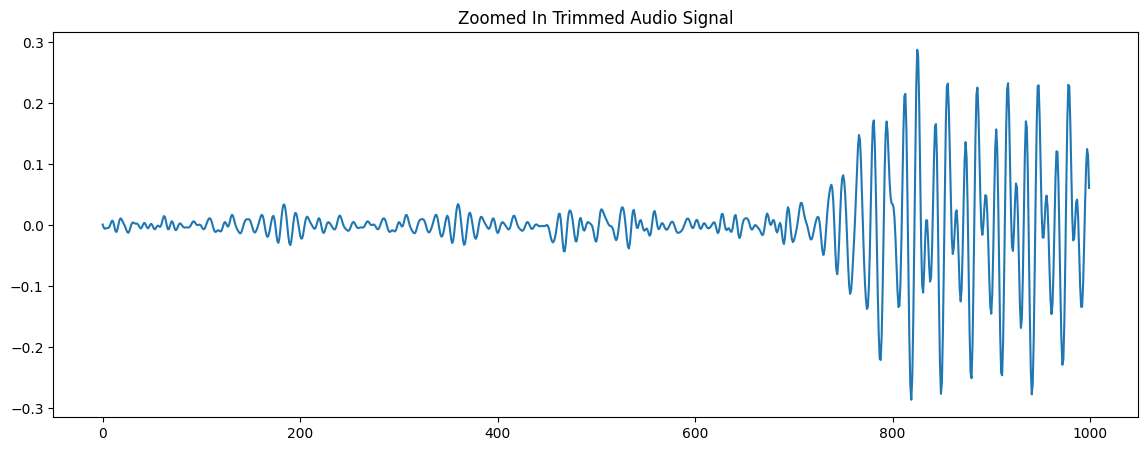

In [18]:
# zoom in on the first 1000 samples of the trimmed audio signal
pd.Series(y_trimmed[:1000]).plot(figsize=(14, 5))
plt.title("Zoomed In Trimmed Audio Signal")


**Fourier transform** - Plots frequency of audio sample to intensity (instead of intensity vs time)

(1025, 49)


Text(0.5, 1.0, 'Spectrogram (dB)')

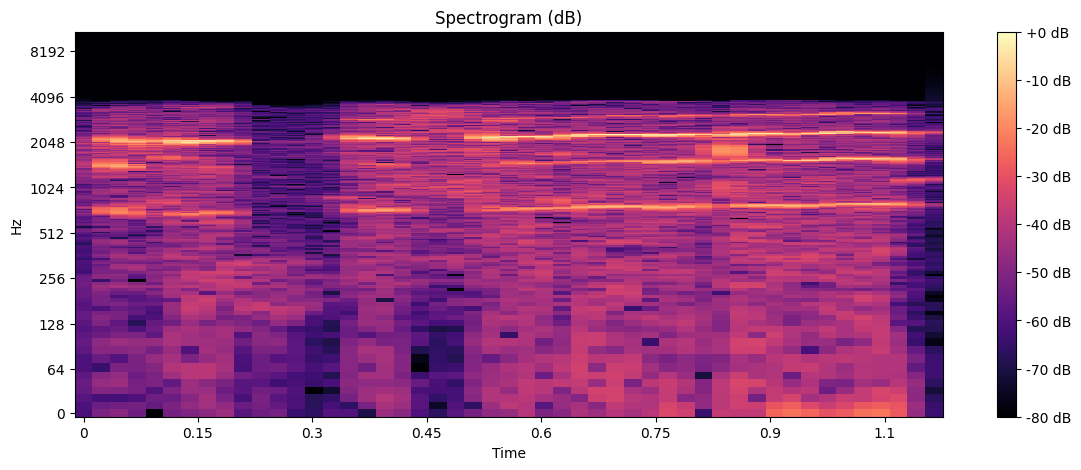

In [24]:
# short-time fourier transform (STFT) to get the spectrogram of the audio signal
D = librosa.stft(y_trimmed, n_fft=2048, hop_length=512)

# convert the amplitude to decibels
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
print(S_db.shape)
# plot the spectrogram using librosa's display module
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (dB)")


**MELL Spectrogram** - Specialized spectrogram that uses a different, non-linear scale to match how humans actually perceive sound
- Humans are better at detecting differences between lower pitches than higher pitches
- We also perceive loudness logarithmically instead of linearly
- It basically "stretches" the low frequencies where humans are the most sensitive, and "compresses" the higher frequencies

In [25]:
# use librosa.feature.melspectrogram to get the mel spectrogram of the audio signal
S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
S_db_mel = librosa.power_to_db(S, ref=np.max)
print(S_db_mel.shape)

(128, 49)


Text(0.5, 1.0, 'Mel Spectrogram (dB)')

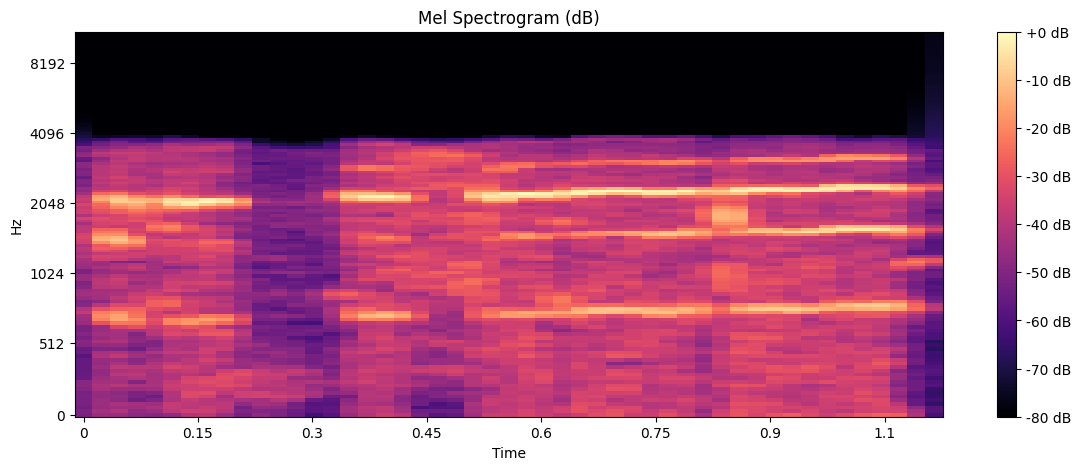

In [26]:
# plot the spectrogram of the audio signal
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram (dB)")
